# Köhler Illumination Microscopy


#AIM:
To demonstrate the setup and alignment of a Köhler illumination using optical
components.

#Apparatus


1. Lamp
2. Collector Lens
3. Field stop (iris)
4. Flip mount filters
5. ND filters wheel
6. Condenser
7. Sample Stage
8. Objective
9. Camera



# Theory
Köhler illumination provides uniform illumination across the entire field of view, which
is essential for producing high-quality images. This uniformity eliminates shadows and bright
spots, ensuring that the specimen is illuminated evenly.It is a method of specimen illumination in
microscopy that creates parallel light rays to pass through the specimen, eliminating the image
of the light source filament. It was developed by August Köhler in 1893 . Köhler illumination
uses various optical components including a collector lens, field diaphragm, condenser
diaphragm and condenser lens to produce evenly illuminated, high-contrast images without
shadows or glare. It is used in various types of microscopy including brightfield, phase contrast,
darkfield and polarized light microscopy.


# Method
The microscope illumination system is quite subtle and sophisticated, but also
relatively simple. We need to control a few things in the illumination path:
1. Intensity (brightness)
2. Spectrum (color)
3. Location (what part of the sample is illuminated)
4. Uniformity (even illumination across the sample)

We use colour filters to limit the range of wavelengths one is imaging with, and also to prevent chromatic aberration. Green is usually chosen.

Then, we use a lens to collect the light from the filament and focus it toward the sample. The lens is called the "collector lens".
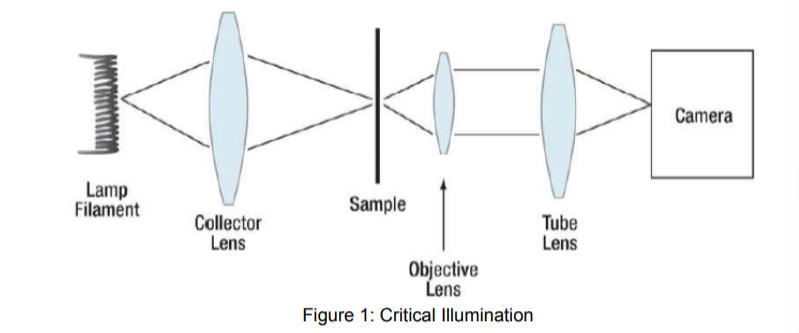

In addition, the filament must also be imaged onto the camera, the filament, sample, and camera face are all imaged onto each other, i.e. are on "conjugate planes":

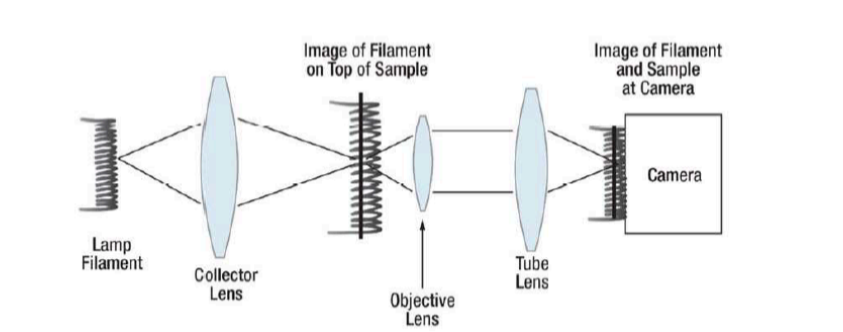

If we put
the sample exactly one focal length on the other side of the lens then each point in the filament
would illuminate the entire sample resulting in complete uniformity. In our lab experiment we need to arrange the
optical components in a systematic way:
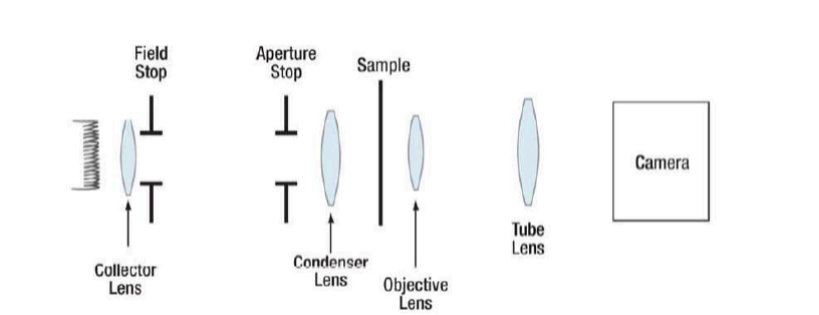


# Analysis

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# Loading the csv file
black = pd.read_csv('black_data.csv')
white = pd.read_csv('white_data.csv')

In [15]:
black_625 = black['625']
black_1250 = black['1250']
black_2500 = black['2500']
black_5000 = black['5000']
black_10000 = black['10000']
black_20000 = black['20000']

white_625 = white['625']
white_1250 = white['1250']
white_2500 = white['2500']
white_5000 = white['5000']
white_10000 = white['10000']
white_20000 = white['20000']

In [16]:
# Contrast
def contrast(Imax,Imin):
  return (Imax-Imin)/(Imax+Imin)

In [17]:
gratings = {"6.25 LP/MM": "625","12.5 LP/MM": "1250","25 LP/MM": "2500","50 LP/MM": "5000","100 LP/MM": "10000","200 LP/MM": "20000"}

rows = []
for label, key in gratings.items():
  W = white[key]   # without filter
  B = black[key]   # with filter
  Imax_W = np.max(W)
  Imin_W = np.min(W)
  C_W = contrast(Imax_W,Imin_W)
  Imax_G = np.max(B)
  Imin_G = np.min(B)
  C_G = contrast(Imax_G,Imin_G)
  rows.append([label,Imax_W, Imax_G,Imin_W, Imin_G,C_W, C_G])

columns = ["Grating","Imax (White)", "Imax (Green)","Imin (White)", "Imin (Green)","Contrast (White)", "Contrast (Green)"]
df = pd.DataFrame(rows, columns=columns).round(3)
print(df)
df.to_csv("contrast_table.csv", index=False)

      Grating  Imax (White)  Imax (Green)  Imin (White)  Imin (Green)  \
0  6.25 LP/MM       105.477       254.000        15.843        18.180   
1  12.5 LP/MM       103.019       254.000        14.522        15.021   
2    25 LP/MM       102.488       254.000        17.553        15.228   
3    50 LP/MM        99.067       254.000        14.600        11.409   
4   100 LP/MM        85.412       254.000        21.294        15.556   
5   200 LP/MM        50.000       135.227        38.286        19.750   

   Contrast (White)  Contrast (Green)  
0             0.739             0.866  
1             0.753             0.888  
2             0.708             0.887  
3             0.743             0.914  
4             0.601             0.885  
5             0.133             0.745  


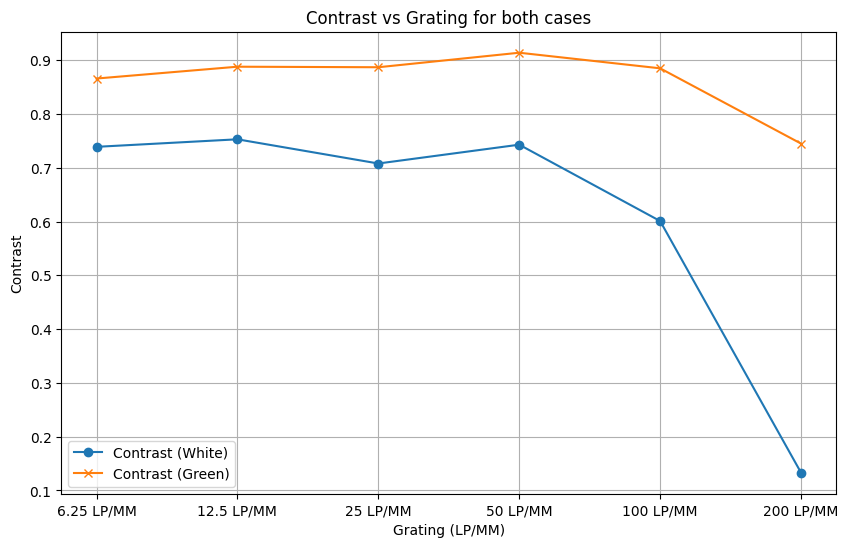

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(df['Grating'], df['Contrast (White)'], marker='o', label='Contrast (White)')
plt.plot(df['Grating'], df['Contrast (Green)'], marker='x', label='Contrast (Green)')
plt.xlabel('Grating (LP/MM)')
plt.ylabel('Contrast')
plt.title('Contrast vs Grating for both cases')
plt.grid(True)
plt.legend()
plt.show()

# Results

Here is the table prepared for contrast with different gratings -
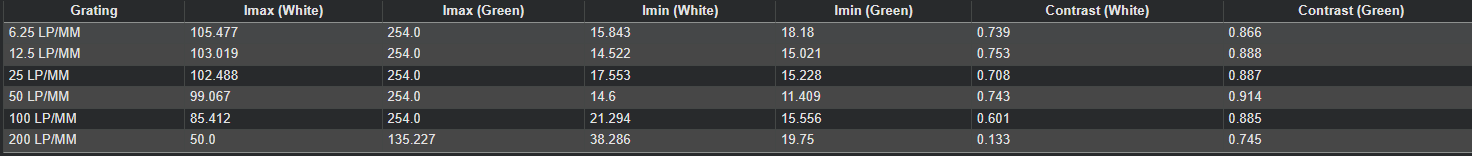

The images taken during experiment can be found at: \
https://drive.google.com/file/d/1c9TCMIMv6OqQvLSohG5h5wiak0yOORWc/view?usp=sharing